# Feature Engineering

**Project:** Customer Churn Prediction & Business Intelligence System

This notebook prepares the feature-engineered dataset for later statistical analysis and  model development.

### Main tasks
- Load the cleaned  dataset.
- Validate the dataset and target.
- Check/remove leakage and identifier fields.
- Investigate redundant variables.
- Create tenure, spending, contract, service, and interaction features.
- Review churn rates for engineered features.
- Examine numerical correlations.
- Save the feature-engineered dataset and supporting outputs.

> **Target variable:** `Churn Value`  
> `1 = Churned`, `0 = Retained`


In [1]:
# 1. Import libraries

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project paths

The notebook automatically searches upward for the repository root, so it can be run from VS Code even if the current working directory changes.

In [2]:
# 2. Locate the repository and define input/output paths

current_path = Path.cwd().resolve()

def find_repo_root(start_path):
    for path in [start_path] + list(start_path.parents):
        expected_file = path / "Cleaned Dataset" / "customer_churn_cleaned.xlsx"
        if expected_file.exists():
            return path
    raise FileNotFoundError(
        "Could not locate the repository root. Make sure the notebook is inside the project "
        "and 'Cleaned Dataset/customer_churn_cleaned.xlsx' exists."
    )

repo_root = find_repo_root(current_path)

group3_dir = repo_root / "Feature Engineering & Statistical Analysis"
output_dir = group3_dir / "outputs"
figures_dir = group3_dir / "figures"

output_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

data_path = repo_root / "Cleaned Dataset" / "customer_churn_cleaned.xlsx"

print("Repository root :", repo_root)
print("Input dataset   :", data_path)
print("Output folder   :", output_dir)
print("Figures folder  :", figures_dir)

Repository root : D:\DS intern\Task\Group\Week 05\Customer-Churn-Prediction-Business-Intelligence-System
Input dataset   : D:\DS intern\Task\Group\Week 05\Customer-Churn-Prediction-Business-Intelligence-System\Cleaned Dataset\customer_churn_cleaned.xlsx
Output folder   : D:\DS intern\Task\Group\Week 05\Customer-Churn-Prediction-Business-Intelligence-System\Feature Engineering & Statistical Analysis\outputs
Figures folder  : D:\DS intern\Task\Group\Week 05\Customer-Churn-Prediction-Business-Intelligence-System\Feature Engineering & Statistical Analysis\figures


## 2. Load the cleaned dataset

Group 3 uses the **unscaled cleaned dataset** (`Model_Ready_Data`) so that feature engineering remains business-interpretable. Scaling/encoding for machine learning should be handled later inside the Group 4 training pipeline.

In [3]:
# 3. Load Group 1 cleaned data

df = pd.read_excel(
    data_path,
    sheet_name="Model_Ready_Data"
)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Dataset loaded successfully: 7,043 rows × 23 columns


,Zip Code,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Frequency,Monthly Charges,Total Charges,Churn Value,CLTV
0,90003,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,0,3,53.85,108.15,1,107.7
1,90005,Female,0,0,1,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,0,1,70.70,151.65,1,141.4
2,90006,Female,0,0,1,8,1,1,Fiber optic,0,0,1,0,1,1,Month-to-month,1,0,5,99.65,820.50,1,797.2
3,90010,Female,0,1,1,28,1,1,Fiber optic,0,0,1,1,1,1,Month-to-month,1,0,6,104.80,3046.05,1,2934.4
4,90015,Male,0,0,1,49,1,1,Fiber optic,0,1,1,0,1,1,Month-to-month,1,1,6,103.70,5036.30,1,5081.3


## 3. Initial validation

In [4]:
# 4. Basic validation

print("Shape:", df.shape)
print("\nMissing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

print("\nColumns:")
for col in df.columns:
    print("-", col)

print("\nTarget distribution:")
target_counts = df["Churn Value"].value_counts().sort_index()
target_pct = df["Churn Value"].value_counts(normalize=True).sort_index().mul(100).round(2)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_pct
})
display(target_summary)

Shape: (7043, 23)

Missing values: 0
Duplicate rows: 0

Columns:
- Zip Code
- Gender
- Senior Citizen
- Partner
- Dependents
- Tenure Months
- Phone Service
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies
- Contract
- Paperless Billing
- Payment Method
- Total Frequency
- Monthly Charges
- Total Charges
- Churn Value
- CLTV

Target distribution:


,Count,Percentage
Churn Value,,
0,5174,73.46
1,1869,26.54


In [5]:
# 5. Keep an untouched copy for reference

df_original = df.copy()
print("Original dataset backup created.")

Original dataset backup created.


## 4. Leakage and identifier checks

Features such as `Churn Label`, `Churn Score`, or `Churn Reason` would reveal information about the target and must not be used as predictors. `Zip Code` is treated as a high-cardinality location identifier in this Group 3 feature set.

In [6]:
# 6. Remove known target-leakage fields if present

leakage_columns = ["Churn Label", "Churn Score", "Churn Reason"]
leakage_found = [col for col in leakage_columns if col in df.columns]

if leakage_found:
    df = df.drop(columns=leakage_found)
    print("Removed leakage columns:", leakage_found)
else:
    print("No known leakage columns are present in Model_Ready_Data.")

No known leakage columns are present in Model_Ready_Data.


In [7]:
# 7. Remove Zip Code from the predictive feature set

if "Zip Code" in df.columns:
    df = df.drop(columns=["Zip Code"])
    print("Zip Code removed.")
else:
    print("Zip Code was not present.")

Zip Code removed.


## 5. Redundancy checks

Two important checks are performed before creating new features:

1. **Total Frequency** — verify whether it is exactly the sum of the individual service indicators.
2. **CLTV vs Total Charges** — check whether the two continuous variables carry almost identical information.

In [8]:
# 8. Check whether Total Frequency is perfectly redundant

frequency_columns = [
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

total_frequency_exact = False

if "Total Frequency" in df.columns and all(col in df.columns for col in frequency_columns):
    calculated_frequency = df[frequency_columns].sum(axis=1)
    total_frequency_exact = bool((calculated_frequency == df["Total Frequency"]).all())

    print("Total Frequency exactly equals the service-indicator sum:", total_frequency_exact)

    if total_frequency_exact:
        df = df.drop(columns=["Total Frequency"])
        print("Total Frequency removed because it is perfectly redundant.")
else:
    print("Total Frequency redundancy check could not be completed.")

Total Frequency exactly equals the service-indicator sum: True
Total Frequency removed because it is perfectly redundant.


In [9]:
# 9. Check CLTV vs Total Charges

cltv_correlation = np.nan

if "CLTV" in df.columns and "Total Charges" in df.columns:
    cltv_correlation = float(df["CLTV"].corr(df["Total Charges"]))
    print(f"Correlation between CLTV and Total Charges: {cltv_correlation:.4f}")

    if abs(cltv_correlation) >= 0.95:
        df = df.drop(columns=["CLTV"])
        print("CLTV removed because it is extremely highly correlated with Total Charges.")
else:
    print("CLTV/Total Charges correlation check could not be completed.")

Correlation between CLTV and Total Charges: 0.9996
CLTV removed because it is extremely highly correlated with Total Charges.


## 6. Validate required columns

The engineered features below depend on tenure, contract, monthly charges, internet service, support services, and the churn target.

In [10]:
# 10. Confirm required columns exist

required_columns = [
    "Tenure Months",
    "Contract",
    "Monthly Charges",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Churn Value"
]

missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Required columns missing: {missing_required}")

print("All required columns are available.")

All required columns are available.


# 7. Feature engineering

The following features represent customer lifecycle, price exposure, contract risk, service engagement, and business-relevant interactions.

In [11]:
# 11. Customer lifecycle features

# New customer: tenure of 12 months or less
df["Is_New_Customer"] = (df["Tenure Months"] <= 12).astype(int)

# Tenure bands for customer lifecycle segmentation
df["Tenure_Band"] = pd.cut(
    df["Tenure Months"],
    bins=[-np.inf, 6, 12, 24, 48, np.inf],
    labels=["0-6", "7-12", "13-24", "25-48", "49+"]
)

display(df[["Tenure Months", "Is_New_Customer", "Tenure_Band"]].head(10))

,Tenure Months,Is_New_Customer,Tenure_Band
0,2,1,0-6
1,2,1,0-6
2,8,1,7-12
3,28,0,25-48
4,49,0,49+
5,10,1,7-12
6,1,1,0-6
7,1,1,0-6
8,47,0,25-48
9,1,1,0-6


In [12]:
# 12. Contract and spending features

df["Is_Month_to_Month"] = (df["Contract"] == "Month-to-month").astype(int)

# Use the dataset median as a reproducible, data-driven threshold
monthly_charge_threshold = float(df["Monthly Charges"].median())

df["High_Monthly_Charge"] = (
    df["Monthly Charges"] >= monthly_charge_threshold
).astype(int)

print(f"Monthly charge threshold (median): {monthly_charge_threshold:.2f}")

display(
    df[
        ["Contract", "Is_Month_to_Month", "Monthly Charges", "High_Monthly_Charge"]
    ].head(10)
)

Monthly charge threshold (median): 70.35


,Contract,Is_Month_to_Month,Monthly Charges,High_Monthly_Charge
0,Month-to-month,1,53.85,0
1,Month-to-month,1,70.70,1
2,Month-to-month,1,99.65,1
3,Month-to-month,1,104.80,1
4,Month-to-month,1,103.70,1
5,Month-to-month,1,55.20,0
6,Month-to-month,1,39.65,0
7,Month-to-month,1,20.15,0
8,Month-to-month,1,99.35,1
9,Month-to-month,1,30.20,0


In [13]:
# 13. Interaction/risk features

# Fiber optic customers on month-to-month contracts
df["Fiber_Monthly_Risk"] = (
    (df["Internet Service"] == "Fiber optic")
    & (df["Contract"] == "Month-to-month")
).astype(int)

# New customers with relatively high monthly charges
df["New_High_Spend"] = (
    (df["Tenure Months"] <= 12)
    & (df["Monthly Charges"] >= monthly_charge_threshold)
).astype(int)

# New customers on month-to-month contracts
df["New_Monthly_Customer"] = (
    (df["Tenure Months"] <= 12)
    & (df["Contract"] == "Month-to-month")
).astype(int)

display(
    df[
        [
            "Internet Service",
            "Contract",
            "Tenure Months",
            "Monthly Charges",
            "Fiber_Monthly_Risk",
            "New_High_Spend",
            "New_Monthly_Customer",
        ]
    ].head(10)
)

,Internet Service,Contract,Tenure Months,Monthly Charges,Fiber_Monthly_Risk,New_High_Spend,New_Monthly_Customer
0,DSL,Month-to-month,2,53.85,0,0,1
1,Fiber optic,Month-to-month,2,70.70,1,1,1
2,Fiber optic,Month-to-month,8,99.65,1,1,1
3,Fiber optic,Month-to-month,28,104.80,1,0,0
4,Fiber optic,Month-to-month,49,103.70,1,0,0
5,DSL,Month-to-month,10,55.20,0,0,1
6,DSL,Month-to-month,1,39.65,0,0,1
7,No,Month-to-month,1,20.15,0,0,1
8,Fiber optic,Month-to-month,47,99.35,1,0,0
9,DSL,Month-to-month,1,30.20,0,0,1


In [14]:
# 14. Support/service engagement features

support_columns = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support"
]

df["Support_Service_Count"] = df[support_columns].sum(axis=1)

df["Security_Tech_Bundle"] = (
    (df["Online Security"] == 1)
    & (df["Tech Support"] == 1)
).astype(int)

display(
    df[
        support_columns
        + ["Support_Service_Count", "Security_Tech_Bundle"]
    ].head(10)
)

,Online Security,Online Backup,Device Protection,Tech Support,Support_Service_Count,Security_Tech_Bundle
0,1,1,0,0,2,0
1,0,0,0,0,0,0
2,0,0,1,0,1,0
3,0,0,1,1,2,0
4,0,1,1,0,2,0
5,0,0,1,1,2,0
6,0,0,1,0,1,0
7,0,0,0,0,0,0
8,0,1,0,0,1,0
9,0,1,0,0,1,0


In [15]:
# 15. List engineered features

engineered_features = [
    "Is_New_Customer",
    "Tenure_Band",
    "Is_Month_to_Month",
    "High_Monthly_Charge",
    "Fiber_Monthly_Risk",
    "New_High_Spend",
    "New_Monthly_Customer",
    "Support_Service_Count",
    "Security_Tech_Bundle"
]

print("Engineered features:")
for feature in engineered_features:
    print("-", feature)

Engineered features:
- Is_New_Customer
- Tenure_Band
- Is_Month_to_Month
- High_Monthly_Charge
- Fiber_Monthly_Risk
- New_High_Spend
- New_Monthly_Customer
- Support_Service_Count
- Security_Tech_Bundle


## 8. Quick business validation of engineered features

These summaries are **descriptive**, not the final statistical evidence. Formal hypothesis tests will be performed in `statistical_analysis.ipynb`.

In [16]:
# 16. Churn-rate summary for binary engineered features

binary_engineered_features = [
    "Is_New_Customer",
    "Is_Month_to_Month",
    "High_Monthly_Charge",
    "Fiber_Monthly_Risk",
    "New_High_Spend",
    "New_Monthly_Customer",
    "Security_Tech_Bundle"
]

summary_rows = []

for feature in binary_engineered_features:
    grouped = (
        df.groupby(feature)["Churn Value"]
        .agg(["count", "mean"])
        .reset_index()
    )

    for _, row in grouped.iterrows():
        summary_rows.append({
            "Feature": feature,
            "Value": int(row[feature]),
            "Customer_Count": int(row["count"]),
            "Churn_Rate_Percent": round(float(row["mean"]) * 100, 2)
        })

engineered_feature_summary = pd.DataFrame(summary_rows)
display(engineered_feature_summary)

,Feature,Value,Customer_Count,Churn_Rate_Percent
0,Is_New_Customer,0,4857,17.13
1,Is_New_Customer,1,2186,47.44
2,Is_Month_to_Month,0,3168,6.76
3,Is_Month_to_Month,1,3875,42.71
4,High_Monthly_Charge,0,3519,17.93
5,High_Monthly_Charge,1,3524,35.13
6,Fiber_Monthly_Risk,0,4915,14.38
7,Fiber_Monthly_Risk,1,2128,54.61
8,New_High_Spend,0,6209,20.89
9,New_High_Spend,1,834,68.59


In [17]:
# 17. Churn rate by tenure band

tenure_churn_summary = (
    df.groupby("Tenure_Band", observed=False)["Churn Value"]
    .agg(["count", "mean"])
    .reset_index()
)

tenure_churn_summary["Churn_Rate_Percent"] = (
    tenure_churn_summary["mean"] * 100
).round(2)

tenure_churn_summary = tenure_churn_summary.drop(columns=["mean"])

display(tenure_churn_summary)

,Tenure_Band,count,Churn_Rate_Percent
0,0-6,1481,52.94
1,7-12,705,35.89
2,13-24,1024,28.71
3,25-48,1594,20.39
4,49+,2239,9.51


In [18]:
# 18. Churn rate by support-service count

support_churn_summary = (
    df.groupby("Support_Service_Count")["Churn Value"]
    .agg(["count", "mean"])
    .reset_index()
)

support_churn_summary["Churn_Rate_Percent"] = (
    support_churn_summary["mean"] * 100
).round(2)

support_churn_summary = support_churn_summary.drop(columns=["mean"])

display(support_churn_summary)

,Support_Service_Count,count,Churn_Rate_Percent
0,0,2793,29.75
1,1,1467,38.85
2,2,1372,23.76
3,3,941,12.43
4,4,470,5.32


## 9. Correlation analysis

In [19]:
# 19. Numeric correlation matrix

numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

display(correlation_matrix.round(3))

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Is_New_Customer,Is_Month_to_Month,High_Monthly_Charge,Fiber_Monthly_Risk,New_High_Spend,New_Monthly_Customer,Support_Service_Count,Security_Tech_Bundle
Senior Citizen,1.000,0.016,-0.174,0.017,0.009,0.143,-0.039,0.067,0.059,-0.061,0.105,0.120,0.157,-0.034,0.220,0.103,0.151,-0.029,0.138,0.212,0.244,0.076,-0.005,0.012,-0.059
Partner,0.016,1.000,0.363,0.380,0.018,0.142,0.143,0.141,0.154,0.120,0.125,0.117,-0.015,0.160,0.097,0.318,-0.150,-0.303,-0.281,0.083,-0.116,-0.173,-0.312,0.202,0.133
Dependents,-0.174,0.363,1.000,0.131,0.001,-0.028,0.050,0.003,-0.022,0.029,-0.058,-0.073,-0.119,0.075,-0.144,0.031,-0.249,-0.114,-0.175,-0.126,-0.197,-0.133,-0.137,0.021,0.052
Tenure Months,0.017,0.380,0.131,1.000,0.008,0.332,0.327,0.360,0.361,0.324,0.280,0.286,0.006,0.397,0.248,0.826,-0.352,-0.755,-0.646,0.196,-0.290,-0.407,-0.714,0.496,0.335
Phone Service,0.009,0.018,0.001,0.008,1.000,0.280,-0.093,-0.052,-0.071,-0.096,-0.023,-0.033,0.017,-0.000,0.247,0.113,0.012,-0.008,-0.001,0.328,0.215,0.120,0.000,-0.112,-0.081
Multiple Lines,0.143,0.142,-0.028,0.332,0.280,1.000,0.098,0.202,0.201,0.101,0.257,0.259,0.164,0.113,0.490,0.469,0.040,-0.263,-0.088,0.479,0.200,0.031,-0.236,0.219,0.082
Online Security,-0.039,0.143,0.050,0.327,-0.093,0.098,1.000,0.284,0.275,0.355,0.176,0.187,-0.004,0.175,0.297,0.412,-0.171,-0.241,-0.247,0.156,-0.175,-0.132,-0.234,0.683,0.678
Online Backup,0.067,0.141,0.003,0.360,-0.052,0.202,0.284,1.000,0.304,0.294,0.282,0.275,0.127,0.148,0.442,0.509,-0.082,-0.267,-0.164,0.312,-0.027,-0.100,-0.246,0.685,0.255
Device Protection,0.059,0.154,-0.022,0.361,-0.071,0.201,0.275,0.304,1.000,0.333,0.391,0.402,0.104,0.162,0.483,0.522,-0.066,-0.273,-0.226,0.356,-0.036,-0.069,-0.259,0.696,0.276
Tech Support,-0.061,0.120,0.029,0.324,-0.096,0.101,0.355,0.294,0.333,1.000,0.278,0.279,0.038,0.182,0.338,0.432,-0.165,-0.238,-0.285,0.200,-0.195,-0.127,-0.233,0.709,0.672


In [20]:
# 20. Identify highly correlated numeric feature pairs

high_corr_pairs = []
columns = correlation_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        corr_value = float(correlation_matrix.iloc[i, j])

        if abs(corr_value) >= 0.80:
            high_corr_pairs.append({
                "Feature_1": columns[i],
                "Feature_2": columns[j],
                "Correlation": round(corr_value, 4)
            })

high_correlation_df = pd.DataFrame(high_corr_pairs)

if high_correlation_df.empty:
    print("No numeric feature pairs have |correlation| >= 0.80.")
else:
    display(
        high_correlation_df.sort_values(
            by="Correlation",
            key=lambda s: s.abs(),
            ascending=False
        )
    )

,Feature_1,Feature_2,Correlation
2,Is_New_Customer,New_Monthly_Customer,0.9367
1,Monthly Charges,High_Monthly_Charge,0.8583
0,Tenure Months,Total Charges,0.8262


## 10. Visual checks

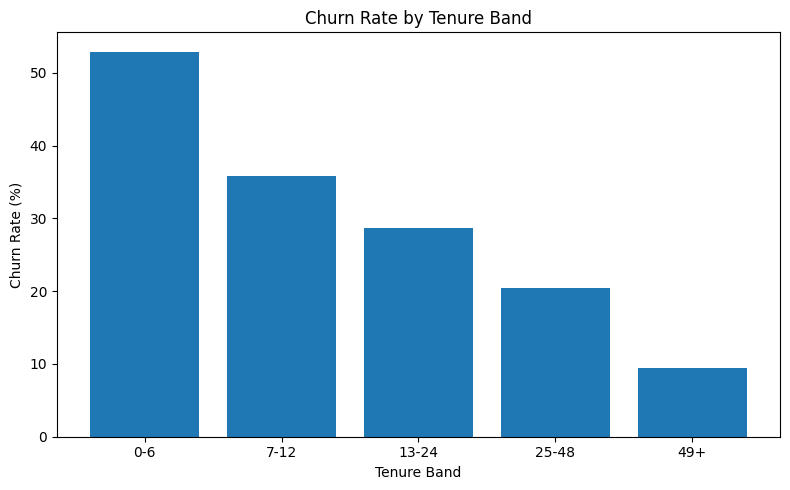

In [21]:
# 21. Churn rate by tenure band

tenure_plot_data = (
    df.groupby("Tenure_Band", observed=False)["Churn Value"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))
plt.bar(tenure_plot_data.index.astype(str), tenure_plot_data.values)
plt.xlabel("Tenure Band")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Tenure Band")
plt.tight_layout()

plt.savefig(
    figures_dir / "churn_rate_by_tenure_band.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

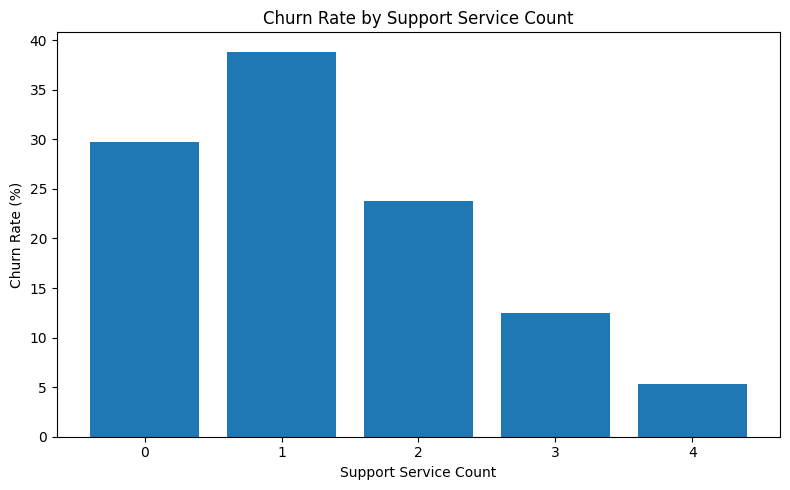

In [22]:
# 22. Churn rate by support service count

support_plot_data = (
    df.groupby("Support_Service_Count")["Churn Value"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(8, 5))
plt.bar(support_plot_data.index.astype(str), support_plot_data.values)
plt.xlabel("Support Service Count")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Support Service Count")
plt.tight_layout()

plt.savefig(
    figures_dir / "churn_rate_by_support_service_count.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

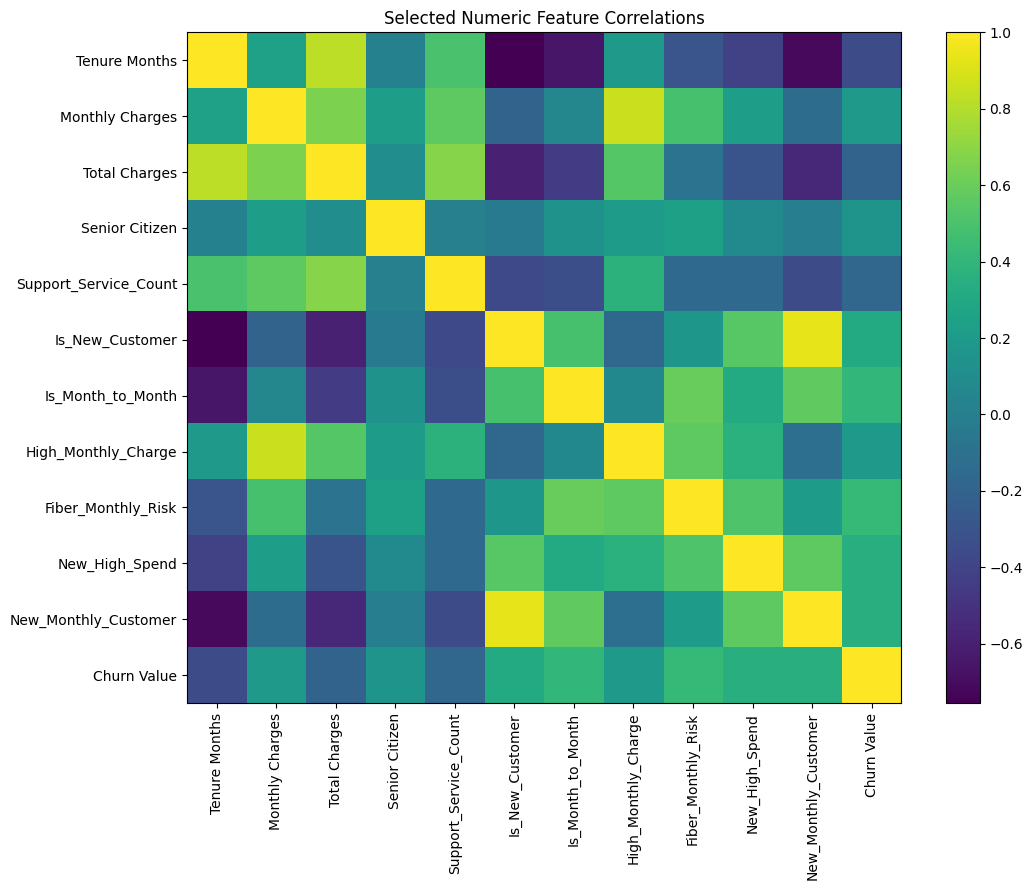

In [23]:
# 23. Selected feature correlation matrix

selected_correlation_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Senior Citizen",
    "Support_Service_Count",
    "Is_New_Customer",
    "Is_Month_to_Month",
    "High_Monthly_Charge",
    "Fiber_Monthly_Risk",
    "New_High_Spend",
    "New_Monthly_Customer",
    "Churn Value"
]

selected_correlation_columns = [
    col for col in selected_correlation_columns if col in df.columns
]

selected_corr = df[selected_correlation_columns].corr()

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(selected_corr.values, aspect="auto")

ax.set_xticks(np.arange(len(selected_correlation_columns)))
ax.set_yticks(np.arange(len(selected_correlation_columns)))
ax.set_xticklabels(selected_correlation_columns, rotation=90)
ax.set_yticklabels(selected_correlation_columns)

fig.colorbar(image, ax=ax)
ax.set_title("Selected Numeric Feature Correlations")
fig.tight_layout()

fig.savefig(
    figures_dir / "selected_feature_correlation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 11. Feature engineering log

In [24]:
# 24. Create a reproducible feature-engineering log

feature_engineering_log = pd.DataFrame([
    {
        "Action": "Dropped",
        "Feature": "Zip Code",
        "Reason": "High-cardinality location identifier; excluded from the predictive feature set."
    },
    {
        "Action": "Leakage Check",
        "Feature": "Churn Label, Churn Score, Churn Reason",
        "Reason": "Excluded if present because they can reveal target/outcome information."
    },
    {
        "Action": "Dropped" if total_frequency_exact else "Checked",
        "Feature": "Total Frequency",
        "Reason": (
            "Exact sum of the individual service indicator columns."
            if total_frequency_exact
            else "Redundancy check performed; not confirmed as an exact sum."
        )
    },
    {
        "Action": "Dropped" if (not pd.isna(cltv_correlation) and abs(cltv_correlation) >= 0.95) else "Checked",
        "Feature": "CLTV",
        "Reason": (
            f"Correlation with Total Charges = {cltv_correlation:.4f}."
            if not pd.isna(cltv_correlation)
            else "Correlation with Total Charges could not be calculated."
        )
    },
    {
        "Action": "Created",
        "Feature": "Is_New_Customer",
        "Reason": "Identifies customers with tenure <= 12 months."
    },
    {
        "Action": "Created",
        "Feature": "Tenure_Band",
        "Reason": "Segments customers into lifecycle/tenure stages."
    },
    {
        "Action": "Created",
        "Feature": "Is_Month_to_Month",
        "Reason": "Identifies month-to-month contract customers."
    },
    {
        "Action": "Created",
        "Feature": "High_Monthly_Charge",
        "Reason": f"Identifies monthly charges >= dataset median ({monthly_charge_threshold:.2f})."
    },
    {
        "Action": "Created",
        "Feature": "Fiber_Monthly_Risk",
        "Reason": "Interaction: fiber-optic service + month-to-month contract."
    },
    {
        "Action": "Created",
        "Feature": "New_High_Spend",
        "Reason": "Interaction: new customer + relatively high monthly charge."
    },
    {
        "Action": "Created",
        "Feature": "New_Monthly_Customer",
        "Reason": "Interaction: new customer + month-to-month contract."
    },
    {
        "Action": "Created",
        "Feature": "Support_Service_Count",
        "Reason": "Count of Online Security, Online Backup, Device Protection, and Tech Support."
    },
    {
        "Action": "Created",
        "Feature": "Security_Tech_Bundle",
        "Reason": "Identifies customers with both Online Security and Tech Support."
    }
])

display(feature_engineering_log)

,Action,Feature,Reason
0,Dropped,Zip Code,High-cardinality location identifier; excluded...
1,Leakage Check,"Churn Label, Churn Score, Churn Reason",Excluded if present because they can reveal ta...
2,Dropped,Total Frequency,Exact sum of the individual service indicator ...
3,Dropped,CLTV,Correlation with Total Charges = 0.9996.
4,Created,Is_New_Customer,Identifies customers with tenure <= 12 months.
5,Created,Tenure_Band,Segments customers into lifecycle/tenure stages.
6,Created,Is_Month_to_Month,Identifies month-to-month contract customers.
7,Created,High_Monthly_Charge,Identifies monthly charges >= dataset median (...
8,Created,Fiber_Monthly_Risk,Interaction: fiber-optic service + month-to-mo...
9,Created,New_High_Spend,Interaction: new customer + relatively high mo...


## 12. Final data-quality check

In [25]:
# 25. Final validation

print("Final shape:", df.shape)
print("Total missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

print("\nFinal columns:")
for col in df.columns:
    print("-", col)

Final shape: (7043, 29)
Total missing values: 0
Duplicate rows: 26

Final columns:
- Gender
- Senior Citizen
- Partner
- Dependents
- Tenure Months
- Phone Service
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies
- Contract
- Paperless Billing
- Payment Method
- Monthly Charges
- Total Charges
- Churn Value
- Is_New_Customer
- Tenure_Band
- Is_Month_to_Month
- High_Monthly_Charge
- Fiber_Monthly_Risk
- New_High_Spend
- New_Monthly_Customer
- Support_Service_Count
- Security_Tech_Bundle


## 13. Save Group 3 outputs

The main file for the next notebook and Group 4 is:

`outputs/customer_churn_feature_engineered.csv`

The additional CSV files document the feature-engineering decisions and descriptive summaries.

In [26]:
# 26. Save output files

df.to_csv(
    output_dir / "customer_churn_feature_engineered.csv",
    index=False
)

feature_engineering_log.to_csv(
    output_dir / "feature_engineering_log.csv",
    index=False
)

engineered_feature_summary.to_csv(
    output_dir / "engineered_feature_churn_summary.csv",
    index=False
)

tenure_churn_summary.to_csv(
    output_dir / "tenure_churn_summary.csv",
    index=False
)

support_churn_summary.to_csv(
    output_dir / "support_service_churn_summary.csv",
    index=False
)

correlation_matrix.to_csv(
    output_dir / "numeric_correlation_matrix.csv"
)

high_correlation_df.to_csv(
    output_dir / "high_correlation_pairs.csv",
    index=False
)

print("All feature-engineering outputs saved successfully.")
print("\nMain output:")
print(output_dir / "customer_churn_feature_engineered.csv")

All feature-engineering outputs saved successfully.

Main output:
D:\DS intern\Task\Group\Week 05\Customer-Churn-Prediction-Business-Intelligence-System\Feature Engineering & Statistical Analysis\outputs\customer_churn_feature_engineered.csv


## 14. Completion summary

In [27]:
# 27. Final summary

print("=" * 64)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 64)

print(f"Original rows    : {df_original.shape[0]:,}")
print(f"Original columns : {df_original.shape[1]}")
print(f"Final rows       : {df.shape[0]:,}")
print(f"Final columns    : {df.shape[1]}")

print(f"\nMonthly-charge median threshold : {monthly_charge_threshold:.2f}")
print(f"Total Frequency exact redundancy : {total_frequency_exact}")

if not pd.isna(cltv_correlation):
    print(f"CLTV vs Total Charges correlation: {cltv_correlation:.4f}")

print("\nEngineered features:")
for feature in engineered_features:
    print("-", feature)

print("\nNext step: run statistical_analysis.ipynb using the saved feature-engineered CSV.")

FEATURE ENGINEERING COMPLETED
Original rows    : 7,043
Original columns : 23
Final rows       : 7,043
Final columns    : 29

Monthly-charge median threshold : 70.35
Total Frequency exact redundancy : True
CLTV vs Total Charges correlation: 0.9996

Engineered features:
- Is_New_Customer
- Tenure_Band
- Is_Month_to_Month
- High_Monthly_Charge
- Fiber_Monthly_Risk
- New_High_Spend
- New_Monthly_Customer
- Support_Service_Count
- Security_Tech_Bundle

Next step: run statistical_analysis.ipynb using the saved feature-engineered CSV.
